In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch import optim
from tqdm.notebook import trange
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from GINN.ph.ph_manager import PHManager
# from GINN.ph.ph_distributed import calc_3d_ph_4d_array
from models.net_w_partials import NetWithPartials
from models.NN import GeneralNet, ConditionalGeneralNet

# torch.manual_seed(0)
device = 'cpu' #if torch.cuda.is_available() else 'cpu'
torch.set_default_device(device)

In [ ]:
## Helper for plotting 
def generate_x_grid(n_grid_points, nx, bounds):
    ### generate x_grid for ph loss
    x_mesh = np.meshgrid(*[np.linspace(*bound, n_grid_points) for bound in bounds])
    # x_mesh_flat = [x.flatten() for x in x_mesh]
    xs = np.vstack([x.ravel() for x in x_mesh]).T
    xs = torch.tensor(xs, dtype=torch.float)
    xs_flat = xs.clone().detach()
    xs = xs.reshape(*(n_grid_points,)*nx, nx)
    return xs, xs_flat

True tensor(0.6095, grad_fn=<SumBackward0>)
You should initialize the network so that the sub-level set is disconnected. This is indicated by success=True.
If so, you proceed to train with the loss in the next cell.


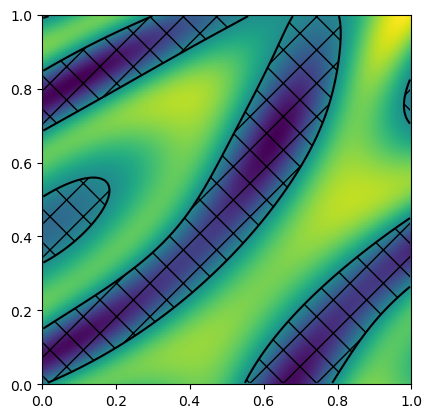

In [221]:
def act(x):
    return torch.sin(8*x)
model = ConditionalGeneralNet(ks=[2,3,3,1], act=act)
netp = NetWithPartials.create_from_model(model, nz=1, nx=2)
## NOTE: the PHManager is implemented in a way where it loops over shapes, so it somehow expects a list of latent codes.
## You could put nz=0 (number of latent dimenions) to 0 here as well, but passing some argument of length 1 is important later ie
## ph_manager.calc_ph_loss_cripser(z=torch.zeros([1,0]))

bounds = torch.tensor([[0,1], [0,1]])

## Define the function to check if query points a are inside the envelope, which in this case is trivially the bounds.
## Since the query points will be in the bounds per construction, we could've also just returned True without checking.
def is_inside_envelope(a: torch.Tensor):
    """Get mask for points which are inside the envelope"""
    is_inside_mask = (
        (a[:, 0] >= bounds[0, 0]) & 
        (a[:, 0] <= bounds[0, 1]) & 
        (a[:, 1] >= bounds[1, 0]) & 
        (a[:, 1] <= bounds[1, 1])
        )
    return is_inside_mask


ph_manager = PHManager(
    mp_pool = None, ## we wont need parallelization
    nx = 2, ## dimension of input
    bounds = bounds, ## bounds of the rectangular domain, list of (min, max) pairs for each coordinate
    netp = netp, ## model in the functional form
    scc_n_grid_points = 128, ## nof grid points along each dimension. this grid is used to perform the discrete PH calculation
    func_inside_envelope = is_inside_envelope, ## a function to mask the points outside the envelope as these would create illegal connections. In the obstacle problem, we do not really need this.
    ph_1_hole_level = 0.1, ## persistence of holes. Ignore this if ph_loss_maxdim=0 (only 0-PH ie connectedness is optimized for)
    ph_loss_target_betti = [1,0,0], ## Target Betti-numers for each dim-PH. Connectedness means 1 for dim=0. Others can be ignored if ph_loss_maxdim=0.
    iso_level = 0, ## level defining the boundary. This also enforces the thickness of the thinest feature for an SDF. NOTE 
    ph_loss_sub0_points = False,
    ph_loss_super0_points = False,
    simjeb_root_dir = "", ## leave empty
    problem_str= "", ## leave empty
    ph_loss_maxdim=0, ## connectedness only
    is_density=False, ## is the implicit function a density field? (no for an SDF)
)

success, loss_scc, _, _ = ph_manager.calc_ph_loss_cripser(z=torch.zeros([1,0])) ## NOTE: the comment at the start of the cell
print(success, loss_scc)
print("You should initialize the network so that the sub-level set is disconnected. This is indicated by success=True.")
print("If so, you proceed to train with the loss in the next cell.")


## Plot the shape for sanity
X, xs_flat = ph_manager.xs, ph_manager.xs_flat
ys_flat = model(xs_flat, torch.zeros(len(xs_flat),0))
Y = ys_flat.reshape(X.shape[0], X.shape[1])
Y_np = Y.detach().cpu().numpy()

fig, ax = plt.subplots()
## Function
ax.imshow(Y_np, extent=bounds.flatten(), origin="lower")
## Level-set
ax.contour(Y_np, extent=bounds.flatten().numpy(), origin="lower", levels=[0], colors='k')
## Sub-level set
ax.contourf(Y_np, extent=bounds.flatten().numpy(), origin="lower", levels=[-np.inf, 0], colors='r', hatches="XX", alpha=0.0)
plt.show()

## Optimize

  0%|          | 0/100 [00:00<?, ?it/s]

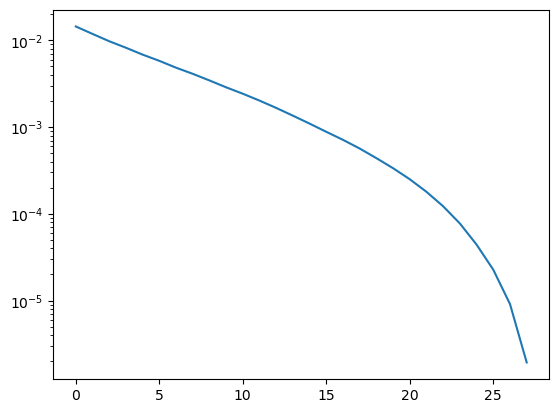

In [215]:
optim = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_over_iters = {}

for i in (pbar:=trange(100)):
    optim.zero_grad()

    success, loss_ph, _, _ = ph_manager.calc_ph_loss_cripser(z=torch.zeros([1,0]))
    if not success:
        ## this means the shape is connected and we can stop. For combining with other losses, just use loss_ph=torch.tensor(0) or smth like that.
        break

    loss = loss_ph
    loss.backward()
    optim.step()

    pbar.set_description(f"connectedness: {loss_ph.item():.2e}")
    loss_over_iters[i] = loss.item()

plt.plot(loss_over_iters.keys(), loss_over_iters.values())
plt.semilogy()
plt.show()

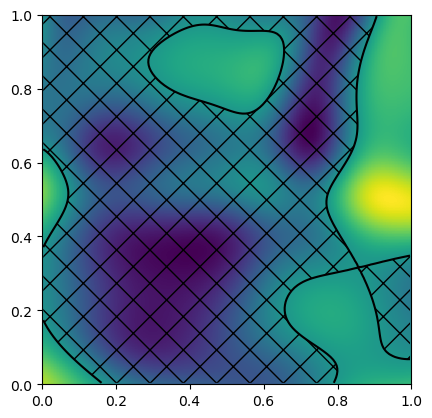

In [ ]:
## Plot the shape after training
X, xs_flat = ph_manager.xs, ph_manager.xs_flat
ys_flat = model(xs_flat, torch.zeros(len(xs_flat),0))
Y = ys_flat.reshape(X.shape[0], X.shape[1])
Y_np = Y.detach().cpu().numpy()

fig, ax = plt.subplots()
## Function
ax.imshow(Y_np, extent=bounds.flatten(), origin="lower")
## Level-set
ax.contour(Y_np, extent=bounds.flatten().numpy(), origin="lower", levels=[0], colors='k')
## Sub-level set
ax.contourf(Y_np, extent=bounds.flatten().numpy(), origin="lower", levels=[-np.inf, 0], colors='r', hatches="XX", alpha=0.0)
plt.show()

You should see how the disconnected components have been connected!